In [29]:
import pickle

with open('NL_dspy/turn_away5.pkl', 'rb') as f:
    data = pickle.load(f)

In [25]:
for kf in data.keyframes:
    print(kf)

name='k1' where=PredicateExpr(op='AND', atom=None, args=[PredicateExpr(op='ATOM', atom=PredicateAtom(type='dist_within_two_obj', obj='car1', other_obj='car2', value=12.0, tol=None, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='dist_within_two_obj', obj='car1', other_obj='car3', value=12.0, tol=None, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='dist_within_two_obj', obj='car2', other_obj='car3', value=12.0, tol=None, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='heading_diff_agent_to_agent', obj='car1', other_obj='car2', value=0.0, tol=30.0, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='heading_diff_agent_to_agent', obj='car1', other_obj='car3', value=0.0, tol=30.0, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='heading_diff_agent_to_agent', obj='car2', other_obj='car3', value=0.0, tol=30.0

In [26]:
def pretty_print_keyframe_data(data):
    """
    Pretty print the keyframe data in a readable format
    """
    print("=" * 80)
    print("KEYFRAME DATA SUMMARY")
    print("=" * 80)
    
    # Print basic info
    print(f"Number of keyframes: {len(data.keyframes)}")
    print(f"Number of constraints: {len(data.constraints)}")
    print(f"Objects: {data.objects.counts}")
    print()
    
    # Print each keyframe
    for i, kf in enumerate(data.keyframes):
        print(f"KEYFRAME {i+1}: {kf.name}")
        print("-" * 40)
        print_predicate_expr(kf.where, indent=0)
        print()
    
    # Print constraints
    if data.constraints:
        print("CONSTRAINTS:")
        print("-" * 40)
        for i, constraint in enumerate(data.constraints):
            print(f"Constraint {i+1}: {constraint.kind}")
            if constraint.kind == "always":
                print(f"  Anchor: {constraint.anchor}")
                print(f"  Target: {constraint.target}")
                print(f"  Duration: {constraint.duration_sec}s")
                print(f"  Tolerance: {constraint.tol}")
            elif constraint.kind == "interframe":
                print(f"  Anchor: {constraint.anchor}")
                print(f"  Target: {constraint.target}")
                print(f"  Time shift: {constraint.time_shift}s")
                print(f"  Comparators: {constraint.comparators}")
            elif constraint.kind == "trajectory":
                print(f"  Object: {constraint.obj}")
                print(f"  Start: {constraint.start}")
                print(f"  End: {constraint.end}")
                print(f"  Template: {constraint.template}")
                print(f"  Angle: {constraint.angle_rad} rad")
                print(f"  Deviation strength: {constraint.deviation_strength}")
            print()

def print_predicate_expr(expr, indent=0):
    """
    Recursively print a predicate expression with proper indentation
    """
    spaces = "  " * indent
    
    if expr.op == "ATOM":
        atom = expr.atom
        print(f"{spaces}• {atom.type}")
        print(f"{spaces}  Object: {atom.obj}")
        if atom.other_obj:
            print(f"{spaces}  Other object: {atom.other_obj}")
        if atom.value is not None:
            print(f"{spaces}  Value: {atom.value}")
        if atom.tol is not None:
            print(f"{spaces}  Tolerance: {atom.tol}")
        if atom.bbox:
            print(f"{spaces}  Bounding box: {atom.bbox}")
        if atom.label:
            print(f"{spaces}  Label: {atom.label}")
    
    elif expr.op == "AND":
        print(f"{spaces}AND (all conditions must be true):")
        for i, arg in enumerate(expr.args):
            print(f"{spaces}  [{i+1}]")
            print_predicate_expr(arg, indent + 2)
    
    elif expr.op == "OR":
        print(f"{spaces}OR (any condition can be true):")
        for i, arg in enumerate(expr.args):
            print(f"{spaces}  [{i+1}]")
            print_predicate_expr(arg, indent + 2)
    
    elif expr.op == "NOT":
        print(f"{spaces}NOT:")
        print_predicate_expr(expr.args[0], indent + 1)

def print_keyframe_summary(data):
    """
    Print a concise summary of all keyframes
    """
    print("KEYFRAME SUMMARY")
    print("=" * 50)
    
    for i, kf in enumerate(data.keyframes):
        print(f"{i+1}. {kf.name}")
        # Count atoms in the predicate
        atom_count = count_atoms(kf.where)
        print(f"   Conditions: {atom_count} predicate(s)")
        
        # Extract object names
        objects = extract_objects(kf.where)
        print(f"   Objects: {', '.join(sorted(objects))}")
        print()

def count_atoms(expr):
    """
    Count the number of atomic predicates in an expression
    """
    if expr.op == "ATOM":
        return 1
    elif expr.args:
        return sum(count_atoms(arg) for arg in expr.args)
    return 0

def extract_objects(expr):
    """
    Extract all object names from a predicate expression
    """
    objects = set()
    
    if expr.op == "ATOM":
        objects.add(expr.atom.obj)
        if expr.atom.other_obj:
            objects.add(expr.atom.other_obj)
    elif expr.args:
        for arg in expr.args:
            objects.update(extract_objects(arg))
    
    return objects


In [30]:
# Pretty print the keyframe data
pretty_print_keyframe_data(data)


KEYFRAME DATA SUMMARY
Number of keyframes: 3
Number of constraints: 3
Objects: {'car': 2}

KEYFRAME 1: k1
----------------------------------------
AND (all conditions must be true):
  [1]
    • dist_apart_two_obj
      Object: car1
      Other object: car2
      Value: 45.0
  [2]
    • heading_diff_agent_to_agent
      Object: car1
      Other object: car2
      Value: 180.0
      Tolerance: 65.0
  [3]
    • is_approaching
      Object: car1
      Other object: car2

KEYFRAME 2: k2
----------------------------------------
AND (all conditions must be true):
  [1]
    • dist_within_two_obj
      Object: car1
      Other object: car2
      Value: 20.0
  [2]
    • velocity_above
      Object: car1
      Value: 0.4
  [3]
    • velocity_above
      Object: car2
      Value: 0.4

KEYFRAME 3: k3
----------------------------------------
AND (all conditions must be true):
  [1]
    • is_separating
      Object: car1
      Other object: car2
  [2]
    • dist_apart_two_obj
      Object: car1
     

In [ ]:
for kf in data.keyframes:
    print(kf)

name='k1' where=PredicateExpr(op='AND', atom=None, args=[PredicateExpr(op='ATOM', atom=PredicateAtom(type='dist_within_two_obj', obj='car1', other_obj='car2', value=12.0, tol=None, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='dist_within_two_obj', obj='car1', other_obj='car3', value=12.0, tol=None, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='dist_within_two_obj', obj='car2', other_obj='car3', value=12.0, tol=None, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='heading_diff_agent_to_agent', obj='car1', other_obj='car2', value=0.0, tol=30.0, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='heading_diff_agent_to_agent', obj='car1', other_obj='car3', value=0.0, tol=30.0, bbox=None, label=None), args=None), PredicateExpr(op='ATOM', atom=PredicateAtom(type='heading_diff_agent_to_agent', obj='car2', other_obj='car3', value=0.0, tol=30.0

In [7]:
# Print a concise summary
print_keyframe_summary(data)


KEYFRAME SUMMARY
1. k1
   Conditions: 9 predicate(s)
   Objects: car1, car2, car3



In [2]:
import pandas as pd
import numpy as np
import os
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns

def sample_dataset_metrics(dataset_path: str, sample_size: int = 10, random_seed: int = 42) -> Dict:
    """
    Sample average metrics from the dataset files.
    
    Args:
        dataset_path: Path to the dataset directory
        sample_size: Number of files to sample
        random_seed: Random seed for reproducibility
    
    Returns:
        Dictionary containing sampled metrics
    """
    np.random.seed(random_seed)
    
    # Get all CSV files
    csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
    print(f"Found {len(csv_files)} CSV files in dataset")
    
    # Sample files
    sampled_files = np.random.choice(csv_files, min(sample_size, len(csv_files)), replace=False)
    print(f"Sampling {len(sampled_files)} files: {sampled_files}")
    
    all_metrics = {
        'dist_within_two_obj': [],
        'heading_diff_agent_to_agent': [],
        'velocities': [],
        'file_info': []
    }
    
    for file_name in sampled_files:
        file_path = os.path.join(dataset_path, file_name)
        print(f"\nProcessing {file_name}...")
        
        try:
            df = pd.read_csv(file_path)
            metrics = calculate_file_metrics(df, file_name)
            
            # Store metrics
            all_metrics['dist_within_two_obj'].extend(metrics['dist_within_two_obj'])
            all_metrics['heading_diff_agent_to_agent'].extend(metrics['heading_diff_agent_to_agent'])
            all_metrics['velocities'].extend(metrics['velocities'])
            all_metrics['file_info'].append(metrics['file_info'])
            
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
            continue
    
    return all_metrics

def calculate_file_metrics(df: pd.DataFrame, file_name: str) -> Dict:
    """
    Calculate metrics for a single file.
    """
    metrics = {
        'dist_within_two_obj': [],
        'heading_diff_agent_to_agent': [],
        'velocities': [],
        'file_info': {
            'file_name': file_name,
            'total_frames': df['frame_index'].max() + 1,
            'unique_objects': df['track_id'].nunique(),
            'object_types': df['class_name'].value_counts().to_dict()
        }
    }
    
    # Get unique track IDs
    track_ids = df['track_id'].unique()
    
    # Calculate velocities for all objects
    for track_id in track_ids:
        obj_data = df[df['track_id'] == track_id]
        if len(obj_data) > 0:
            velocities = np.sqrt(obj_data['vel_x']**2 + obj_data['vel_y']**2)
            metrics['velocities'].extend(velocities.tolist())
    
    # Calculate pairwise distances and heading differences
    for i, track_id1 in enumerate(track_ids):
        for track_id2 in track_ids[i+1:]:  # Avoid duplicates and self-comparison
            obj1_data = df[df['track_id'] == track_id1]
            obj2_data = df[df['track_id'] == track_id2]
            
            if len(obj1_data) == 0 or len(obj2_data) == 0:
                continue
            
            # Calculate distance between objects
            distances = calculate_pairwise_distances(obj1_data, obj2_data)
            if len(distances) > 0:
                metrics['dist_within_two_obj'].extend(distances)
            
            # Calculate heading differences
            heading_diffs = calculate_pairwise_heading_diffs(obj1_data, obj2_data)
            if len(heading_diffs) > 0:
                metrics['heading_diff_agent_to_agent'].extend(heading_diffs)
    
    return metrics

def calculate_pairwise_distances(obj1_data: pd.DataFrame, obj2_data: pd.DataFrame) -> List[float]:
    """
    Calculate distances between two objects across common frames.
    """
    # Merge on frame_index to get common frames
    merged = pd.merge(obj1_data, obj2_data, on='frame_index', suffixes=('_1', '_2'))
    
    if len(merged) == 0:
        return []
    
    # Calculate Euclidean distances
    distances = np.sqrt(
        (merged['x1_1'] - merged['x1_2'])**2 + 
        (merged['y1_1'] - merged['y1_2'])**2
    )
    
    return distances.tolist()

def calculate_pairwise_heading_diffs(obj1_data: pd.DataFrame, obj2_data: pd.DataFrame) -> List[float]:
    """
    Calculate heading differences between two objects across common frames.
    """
    # Merge on frame_index to get common frames
    merged = pd.merge(obj1_data, obj2_data, on='frame_index', suffixes=('_1', '_2'))
    
    if len(merged) == 0:
        return []
    
    # Calculate absolute heading difference
    diff = np.degrees(np.abs(merged['agent_yaw_2'] - merged['agent_yaw_1'])) % 360
    diff = np.where(diff > 180, 360 - diff, diff)
    
    return diff.tolist()

def print_metrics_summary(metrics: Dict):
    """
    Print a summary of the sampled metrics.
    """
    print("=" * 80)
    print("DATASET METRICS SUMMARY")
    print("=" * 80)
    
    # File information
    print(f"Files processed: {len(metrics['file_info'])}")
    total_frames = sum(info['total_frames'] for info in metrics['file_info'])
    total_objects = sum(info['unique_objects'] for info in metrics['file_info'])
    print(f"Total frames: {total_frames}")
    print(f"Total unique objects: {total_objects}")
    
    # Distance metrics
    if metrics['dist_within_two_obj']:
        distances = np.array(metrics['dist_within_two_obj'])
        print(f"\nDISTANCE METRICS:")
        print(f"  Number of distance measurements: {len(distances)}")
        print(f"  Average distance: {distances.mean():.2f} pixels")
        print(f"  Median distance: {np.median(distances):.2f} pixels")
        print(f"  Min distance: {distances.min():.2f} pixels")
        print(f"  Max distance: {distances.max():.2f} pixels")
        print(f"  Std deviation: {distances.std():.2f} pixels")
    
    # Heading difference metrics
    if metrics['heading_diff_agent_to_agent']:
        heading_diffs = np.array(metrics['heading_diff_agent_to_agent'])
        print(f"\nHEADING DIFFERENCE METRICS:")
        print(f"  Number of heading measurements: {len(heading_diffs)}")
        print(f"  Average heading difference: {heading_diffs.mean():.2f} degrees")
        print(f"  Median heading difference: {np.median(heading_diffs):.2f} degrees")
        print(f"  Min heading difference: {heading_diffs.min():.2f} degrees")
        print(f"  Max heading difference: {heading_diffs.max():.2f} degrees")
        print(f"  Std deviation: {heading_diffs.std():.2f} degrees")
    
    # Velocity metrics
    if metrics['velocities']:
        velocities = np.array(metrics['velocities'])
        print(f"\nVELOCITY METRICS:")
        print(f"  Number of velocity measurements: {len(velocities)}")
        print(f"  Average velocity: {velocities.mean():.2f} pixels/frame")
        print(f"  Median velocity: {np.median(velocities):.2f} pixels/frame")
        print(f"  Min velocity: {velocities.min():.2f} pixels/frame")
        print(f"  Max velocity: {velocities.max():.2f} pixels/frame")
        print(f"  Std deviation: {velocities.std():.2f} pixels/frame")

def plot_metrics_distribution(metrics: Dict):
    """
    Create distribution plots for the metrics.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Dataset Metrics Distribution', fontsize=16)
    
    # Distance distribution
    if metrics['dist_within_two_obj']:
        distances = np.array(metrics['dist_within_two_obj'])
        axes[0, 0].hist(distances, bins=50, alpha=0.7, edgecolor='black')
        axes[0, 0].set_title('Distance Between Objects')
        axes[0, 0].set_xlabel('Distance (pixels)')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].axvline(distances.mean(), color='red', linestyle='--', label=f'Mean: {distances.mean():.2f}')
        axes[0, 0].legend()
    
    # Heading difference distribution
    if metrics['heading_diff_agent_to_agent']:
        heading_diffs = np.array(metrics['heading_diff_agent_to_agent'])
        axes[0, 1].hist(heading_diffs, bins=50, alpha=0.7, edgecolor='black')
        axes[0, 1].set_title('Heading Difference Between Agents')
        axes[0, 1].set_xlabel('Heading Difference (degrees)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].axvline(heading_diffs.mean(), color='red', linestyle='--', label=f'Mean: {heading_diffs.mean():.2f}')
        axes[0, 1].legend()
    
    # Velocity distribution
    if metrics['velocities']:
        velocities = np.array(metrics['velocities'])
        axes[1, 0].hist(velocities, bins=50, alpha=0.7, edgecolor='black')
        axes[1, 0].set_title('Object Velocities')
        axes[1, 0].set_xlabel('Velocity (pixels/frame)')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].axvline(velocities.mean(), color='red', linestyle='--', label=f'Mean: {velocities.mean():.2f}')
        axes[1, 0].legend()
    
    # Box plot comparison
    data_for_box = []
    labels_for_box = []
    
    if metrics['dist_within_two_obj']:
        data_for_box.append(metrics['dist_within_two_obj'])
        labels_for_box.append('Distances')
    
    if metrics['heading_diff_agent_to_agent']:
        data_for_box.append(metrics['heading_diff_agent_to_agent'])
        labels_for_box.append('Heading Diffs')
    
    if metrics['velocities']:
        data_for_box.append(metrics['velocities'])
        labels_for_box.append('Velocities')
    
    if data_for_box:
        axes[1, 1].boxplot(data_for_box, labels=labels_for_box)
        axes[1, 1].set_title('Metrics Comparison')
        axes[1, 1].set_ylabel('Values')
    
    plt.tight_layout()
    plt.show()

def analyze_object_types(metrics: Dict):
    """
    Analyze the distribution of object types across sampled files.
    """
    print("\nOBJECT TYPE ANALYSIS:")
    print("-" * 40)
    
    all_types = {}
    for file_info in metrics['file_info']:
        for obj_type, count in file_info['object_types'].items():
            all_types[obj_type] = all_types.get(obj_type, 0) + count
    
    total_objects = sum(all_types.values())
    print(f"Total objects across all sampled files: {total_objects}")
    
    for obj_type, count in sorted(all_types.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / total_objects) * 100
        print(f"  {obj_type}: {count} ({percentage:.1f}%)")


In [3]:
# Sample metrics from the dataset
dataset_path = '/nethome/jxu680/keyframe-ui/dataset'
sample_size = 5  # Adjust this to sample more/fewer files

print("Sampling dataset metrics...")
metrics = sample_dataset_metrics(dataset_path, sample_size=sample_size, random_seed=42)


Sampling dataset metrics...
Found 79 CSV files in dataset
Sampling 5 files: ['scene_scene-0295.csv' 'scene_scene-0228.csv' 'scene_scene-0304.csv'
 'scene_scene-0243.csv' 'scene_scene-0260.csv']

Processing scene_scene-0295.csv...

Processing scene_scene-0228.csv...

Processing scene_scene-0304.csv...

Processing scene_scene-0243.csv...

Processing scene_scene-0260.csv...


In [12]:
# Print detailed metrics summary
print_metrics_summary(metrics)


DATASET METRICS SUMMARY
Files processed: 5
Total frames: 198
Total unique objects: 276

DISTANCE METRICS:
  Number of distance measurements: 72841
  Average distance: 39.81 pixels
  Median distance: 36.18 pixels
  Min distance: 0.34 pixels
  Max distance: 170.64 pixels
  Std deviation: 24.80 pixels

HEADING DIFFERENCE METRICS:
  Number of heading measurements: 72841
  Average heading difference: 84.81 degrees
  Median heading difference: 84.62 degrees
  Min heading difference: 0.00 degrees
  Max heading difference: 180.00 degrees
  Std deviation: 60.63 degrees

VELOCITY METRICS:
  Number of velocity measurements: 5077
  Average velocity: 1.33 pixels/frame
  Median velocity: 0.48 pixels/frame
  Min velocity: 0.00 pixels/frame
  Max velocity: 14.24 pixels/frame
  Std deviation: 2.20 pixels/frame


In [13]:
# Analyze object types
analyze_object_types(metrics)



OBJECT TYPE ANALYSIS:
----------------------------------------
Total objects across all sampled files: 5077
  pedestrian: 2694 (53.1%)
  vehicle: 2189 (43.1%)
  motorcycle: 98 (1.9%)
  bicycle: 96 (1.9%)


/tmp/ipykernel_1066734/2541885746.py:240: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(data_for_box, labels=labels_for_box)


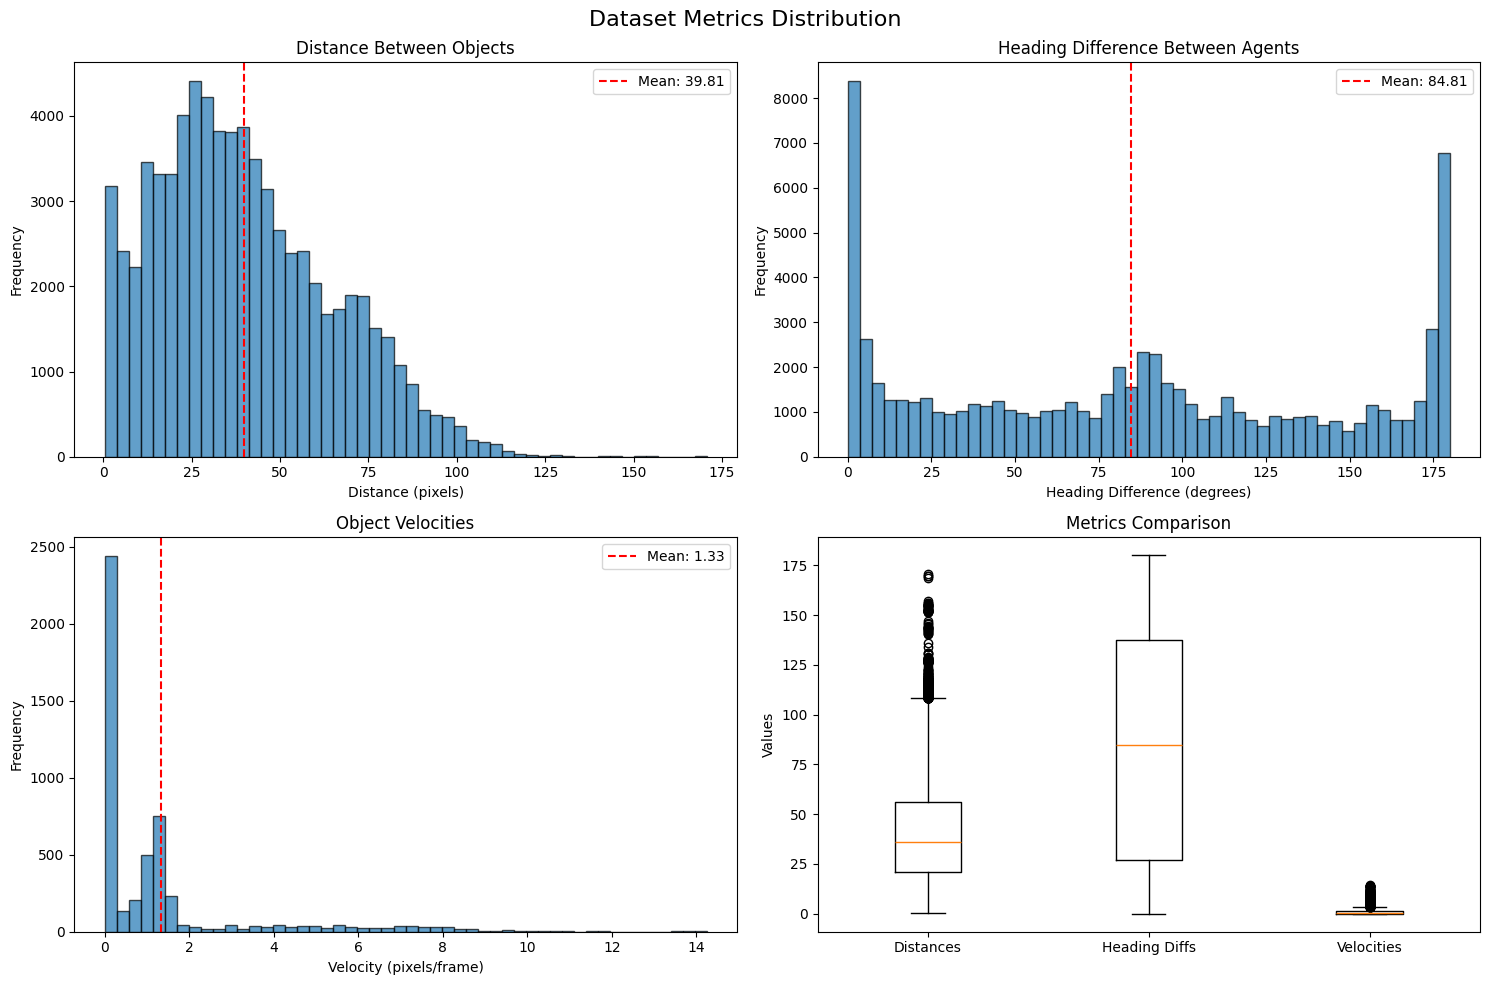

In [14]:
# Create visualization plots
plot_metrics_distribution(metrics)


In [15]:
# Quick access to key averages
print("KEY AVERAGES:")
print("=" * 30)

if metrics['dist_within_two_obj']:
    avg_distance = np.mean(metrics['dist_within_two_obj'])
    print(f"Average distance between objects: {avg_distance:.2f} pixels")

if metrics['heading_diff_agent_to_agent']:
    avg_heading_diff = np.mean(metrics['heading_diff_agent_to_agent'])
    print(f"Average heading difference: {avg_heading_diff:.2f} degrees")

if metrics['velocities']:
    avg_velocity = np.mean(metrics['velocities'])
    print(f"Average velocity: {avg_velocity:.2f} pixels/frame")

# Store averages for easy access
averages = {
    'avg_distance': np.mean(metrics['dist_within_two_obj']) if metrics['dist_within_two_obj'] else None,
    'avg_heading_diff': np.mean(metrics['heading_diff_agent_to_agent']) if metrics['heading_diff_agent_to_agent'] else None,
    'avg_velocity': np.mean(metrics['velocities']) if metrics['velocities'] else None
}

print(f"\nStored averages: {averages}")


KEY AVERAGES:
Average distance between objects: 39.81 pixels
Average heading difference: 84.81 degrees
Average velocity: 1.33 pixels/frame

Stored averages: {'avg_distance': np.float64(39.813697770487614), 'avg_heading_diff': np.float64(84.80814886868083), 'avg_velocity': np.float64(1.3253998508259788)}
